In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_mobile = pd.read_csv("../BDD_initial/mobile_addiction_data.csv", sep="\t", index_col=0)
data_mobile.head()

,Country,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,Gaming_Usage_Hours,...,Internet_Connection_Type,Primary_Device_Brand,Has_Screen_Time_Management_App,Addiction_Level,Monthly_Data_Usage_GB,Has_Night_Mode_On,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score,Addiction_screen
User_ID,,,,,,,,,,,,,,,,,,,,,
1,India,32,Male,Salesperson,High School,"43865,49","5,81",75,"0,84","-1,55",...,5G,Other,No,Low,"16,43",Yes,16,106,"39,36",1
2,UK,26,Male,Artist,Master's,"41868,19","9,05",61,"3,13","2,5",...,4G,Samsung,Yes,Severe,"32,87",No,12,111,"9,45",1
3,Germany,70,Other,Doctor,High School,"59636,51","5,76",58,"2,12","1,96",...,WiFi,Samsung,Yes,Severe,"27,45",No,18,90,"50,27",1
4,UK,44,Female,Engineer,NaN,"39022,07","6,71",80,"1,6","2,7",...,3G,Apple,Yes,Moderate,"30,85",No,17,60,"30,82",1
5,Brazil,46,Other,Student,NaN,"-783,98","6,31",136,"1,51","1,73",...,3G,Xiaomi,No,High,"10,38",Yes,18,127,"21,7",1


In [3]:
data_mobile.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 1 to 3000
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         3000 non-null   object
 1   Age                             3000 non-null   int64 
 2   Gender                          3000 non-null   object
 3   Occupation                      3000 non-null   object
 4   Education_Level                 2388 non-null   object
 5   Income_USD                      3000 non-null   object
 6   Daily_Screen_Time_Hours         3000 non-null   object
 7   Phone_Unlocks_Per_Day           3000 non-null   int64 
 8   Social_Media_Usage_Hours        3000 non-null   object
 9   Gaming_Usage_Hours              3000 non-null   object
 10  Streaming_Usage_Hours           3000 non-null   object
 11  Messaging_Usage_Hours           3000 non-null   object
 12  Work_Related_Usage_Hours        3000 non-null   objec

In [3]:
for col in data_mobile.columns:
    try:
        data_mobile[col] = data_mobile[col].astype(str).str.replace(",", ".").astype(float)
    except:
        pass
addiction_map = {"Low": 1, "Moderate": 2, "High": 3, "Severe": 4}
if data_mobile["Addiction_Level"].dtype == object:
    data_mobile["Addiction_Level"] = data_mobile["Addiction_Level"].map(addiction_map)

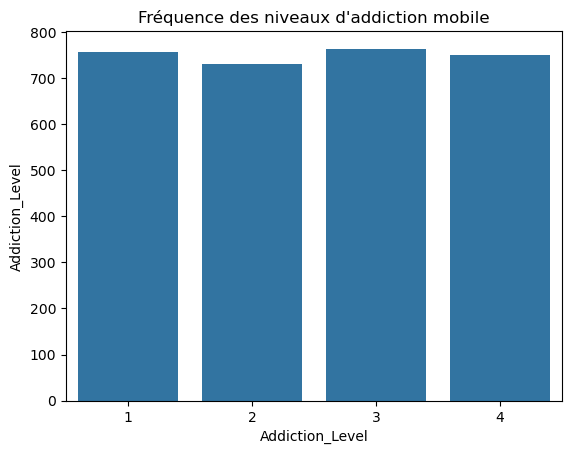

In [5]:
fig = plt.figure()
ax = sns.barplot(data=data_mobile, x="Addiction_Level", y="Addiction_Level", estimator=np.count_nonzero)
ax.set_title("Fréquence des niveaux d'addiction mobile")
plt.show()

C:\Users\sidsm\AppData\Local\Temp\ipykernel_21816\4106313637.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


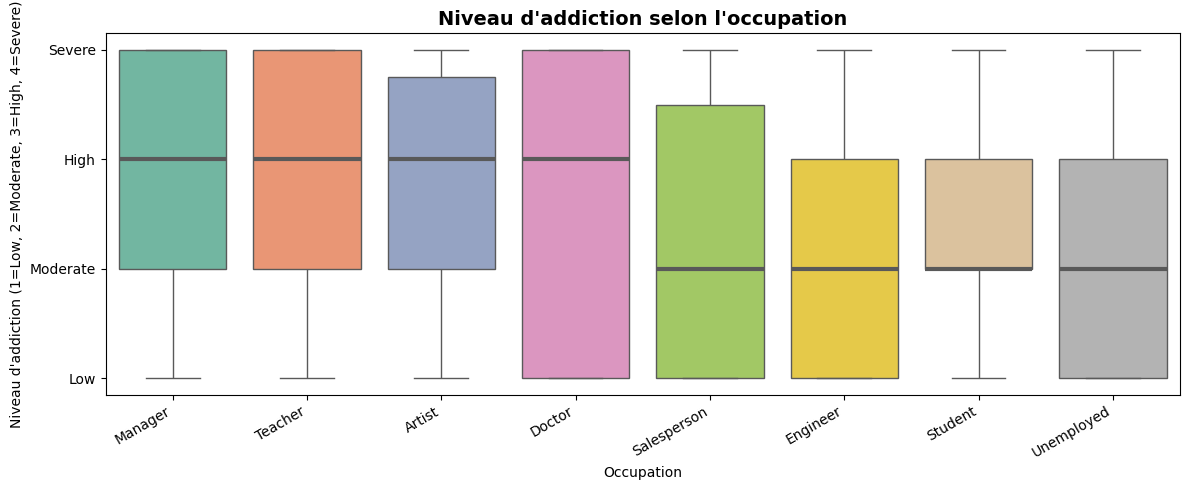

AttributeError: 'Figure' object has no attribute 'write_html'

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

order = (data_mobile.groupby("Occupation")["Addiction_Level"]
           .mean().sort_values(ascending=False).index)

sns.boxplot(
    data=data_mobile,
    x="Occupation",
    y="Addiction_Level",
    order=order, palette="Set2", ax=ax,
    medianprops={"linewidth": 3}
)

ax.set_title("Niveau d'addiction selon l'occupation", fontsize=14, fontweight="bold")
ax.set_xlabel("Occupation")
ax.set_ylabel("Niveau d'addiction (1=Low, 2=Moderate, 3=High, 4=Severe)")
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["Low", "Moderate", "High", "Severe"])
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

fig.write_html("occupation.html")

Selon ce graphique, les managers, professeurs, artistes et docteurs présentent des niveaux d'addiction élevés, suggérant que les professions à forte responsabilité ou pression pourraient être associées à des niveaux d'addiction plus élevés. 

/var/folders/mt/445mmr793_qd4gnxxd5sl8180000gn/T/ipykernel_5620/701756209.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


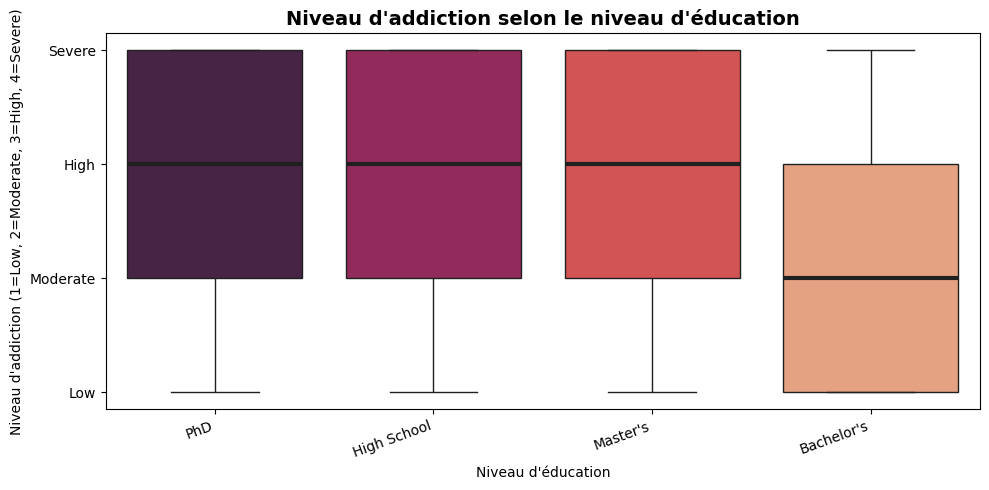

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

order = (data_mobile.groupby("Education_Level")["Addiction_Level"]
           .mean().sort_values(ascending=False).index)

sns.boxplot(
    data=data_mobile,
    x="Education_Level",
    y="Addiction_Level",
    order=order, palette="rocket", ax=ax,
    medianprops={"linewidth": 3}
)

ax.set_title("Niveau d'addiction selon le niveau d'éducation", fontsize=14, fontweight="bold")
ax.set_xlabel("Niveau d'éducation")
ax.set_ylabel("Niveau d'addiction (1=Low, 2=Moderate, 3=High, 4=Severe)")
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["Low", "Moderate", "High", "Severe"])
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

Les différences entre ces variables sont peu marquées, ce qui suggère que le niveau d'éducation n'est pas un facteur fortement discriminant.

/var/folders/mt/445mmr793_qd4gnxxd5sl8180000gn/T/ipykernel_5620/793697372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/mt/445mmr793_qd4gnxxd5sl8180000gn/T/ipykernel_5620/793697372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


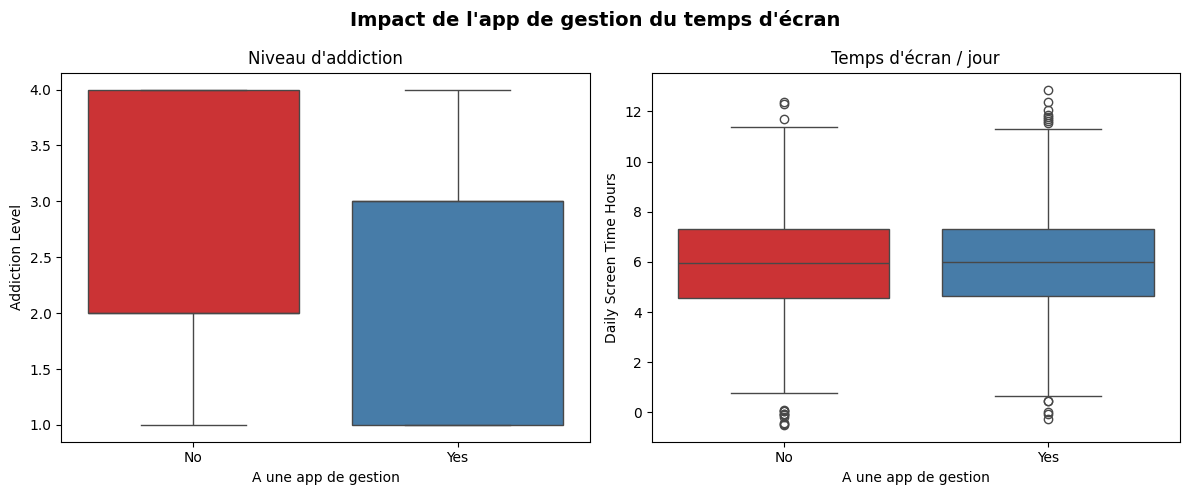

In [ ]:
data_mobile["Daily_Screen_Time_Hours"] = pd.to_numeric(data_mobile["Daily_Screen_Time_Hours"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Impact de l'app de gestion du temps d'écran", fontsize=14, fontweight="bold")

for ax, col, title in zip(
    axes,
    ["Addiction_Level", "Daily_Screen_Time_Hours"],
    ["Niveau d'addiction", "Temps d'écran / jour"]
):
    sns.boxplot(
        data=data_mobile,
        x="Has_Screen_Time_Management_App",
        y=col, palette="Set1", ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("A une app de gestion")
    ax.set_ylabel(col.replace("_", " "))

plt.tight_layout()
plt.show()

Les utilisateurs sans application de gestion présentent un niveau d'addiction médian plus élevé. CEpendant le temps d'écran quotidien moyen reste quasi identique dans les deux groupes ce qui suggère que l'app réduit le sentiment d'addiction sans nécessairement réduire le temps passé sur l'écran.

/var/folders/mt/445mmr793_qd4gnxxd5sl8180000gn/T/ipykernel_5620/3251992026.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


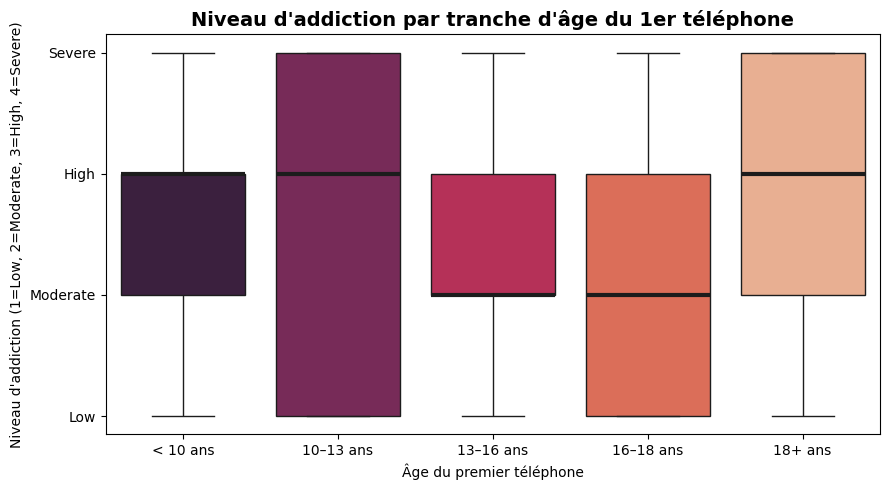

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

data_mobile["Age_First_Phone"] = pd.to_numeric(data_mobile["Age_First_Phone"], errors="coerce")

data_mobile["Age_First_Phone_Group"] = pd.cut(
    data_mobile["Age_First_Phone"],
    bins=[0, 10, 13, 16, 18, 99],
    labels=["< 10 ans", "10–13 ans", "13–16 ans", "16–18 ans", "18+ ans"]
)

sns.boxplot(
    data=data_mobile,
    x="Age_First_Phone_Group",
    y="Addiction_Level",
    palette="rocket", ax=ax,
    medianprops={"linewidth": 3}
)

ax.set_title("Niveau d'addiction par tranche d'âge du 1er téléphone", fontsize=14, fontweight="bold")
ax.set_xlabel("Âge du premier téléphone")
ax.set_ylabel("Niveau d'addiction (1=Low, 2=Moderate, 3=High, 4=Severe)")
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["Low", "Moderate", "High", "Severe"])

plt.tight_layout()
plt.show()

Ces résultats ne montrent pas de tendance linéaire claure entre l'âge du premier téléphone et le niveau d'addiction.

/var/folders/mt/445mmr793_qd4gnxxd5sl8180000gn/T/ipykernel_5620/3253430034.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, x="Country", y="Daily_Screen_Time_Hours",
/var/folders/mt/445mmr793_qd4gnxxd5sl8180000gn/T/ipykernel_5620/3253430034.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, x="Country", y="Addiction_Level",


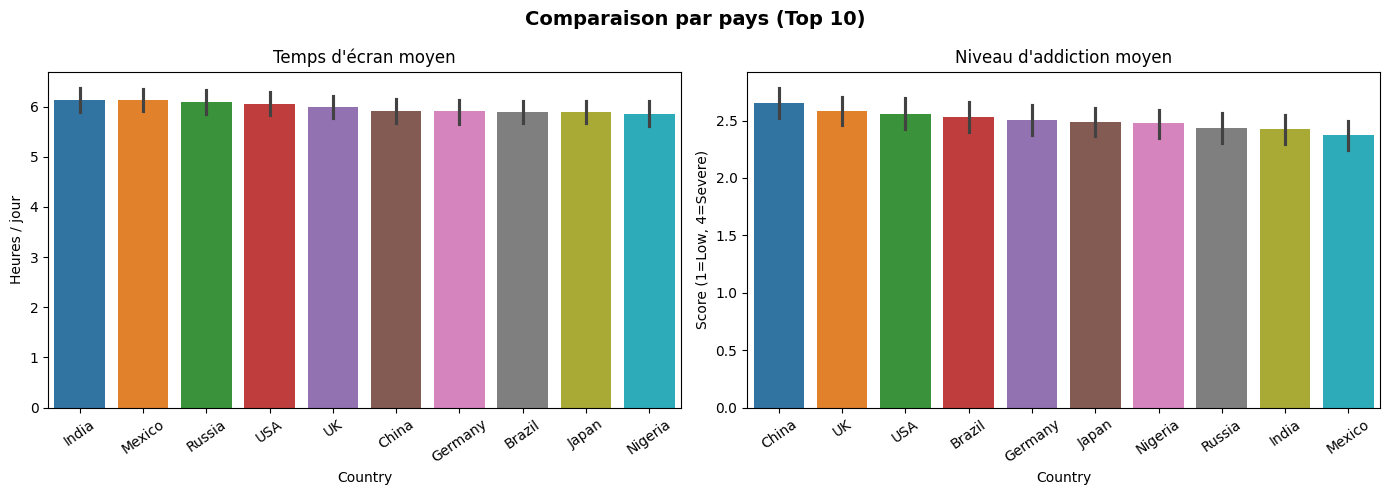

In [ ]:
top_countries = data_mobile["Country"].value_counts().nlargest(10).index
df_top = data_mobile[data_mobile["Country"].isin(top_countries)].copy()
df_top["Daily_Screen_Time_Hours"] = pd.to_numeric(df_top["Daily_Screen_Time_Hours"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison par pays (Top 10)", fontsize=14, fontweight="bold")

order1 = (df_top.groupby("Country")["Daily_Screen_Time_Hours"]
                .mean().sort_values(ascending=False).index)
sns.barplot(data=df_top, x="Country", y="Daily_Screen_Time_Hours",
            order=order1, palette="tab10", ax=axes[0])
axes[0].set_title("Temps d'écran moyen")
axes[0].set_ylabel("Heures / jour")
axes[0].tick_params(axis="x", rotation=35)

order2 = (df_top.groupby("Country")["Addiction_Level"]
                .mean().sort_values(ascending=False).index)
sns.barplot(data=df_top, x="Country", y="Addiction_Level",
            order=order2, palette="tab10", ax=axes[1])
axes[1].set_title("Niveau d'addiction moyen")
axes[1].set_ylabel("Score (1=Low, 4=Severe)")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

Le temps d'écran est homogène entre tout les pays sans différence significative, ce qui confirme que la variable "pays" n'est pas un facteur fortement prédictif dans ce jeu de données.

In [7]:
categorical_cols = data_mobile.columns
categorical_cols

Index(['Country', 'Age', 'Gender', 'Occupation', 'Education_Level',
       'Income_USD', 'Daily_Screen_Time_Hours', 'Phone_Unlocks_Per_Day',
       'Social_Media_Usage_Hours', 'Gaming_Usage_Hours',
       'Streaming_Usage_Hours', 'Messaging_Usage_Hours',
       'Work_Related_Usage_Hours', 'Sleep_Hours', 'Physical_Activity_Hours',
       'Mental_Health_Score', 'Depression_Score', 'Anxiety_Score',
       'Stress_Level', 'Relationship_Status', 'Has_Children', 'Urban_or_Rural',
       'Time_Spent_With_Family_Hours', 'Online_Shopping_Hours',
       'Internet_Connection_Type', 'Primary_Device_Brand',
       'Has_Screen_Time_Management_App', 'Addiction_Level',
       'Monthly_Data_Usage_GB', 'Has_Night_Mode_On', 'Age_First_Phone',
       'Push_Notifications_Per_Day', 'Tech_Savviness_Score',
       'Addiction_screen'],
      dtype='object')

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data_mobile[col] = le.fit_transform(data_mobile[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nAperçu après encodage :")
data_mobile.head()

  Country: {'Brazil': 0, 'China': 1, 'Germany': 2, 'India': 3, 'Japan': 4, 'Mexico': 5, 'Nigeria': 6, 'Russia': 7, 'UK': 8, 'USA': 9}
  Age: {12.0: 0, 13.0: 1, 14.0: 2, 15.0: 3, 16.0: 4, 17.0: 5, 18.0: 6, 19.0: 7, 20.0: 8, 21.0: 9, 22.0: 10, 23.0: 11, 24.0: 12, 25.0: 13, 26.0: 14, 27.0: 15, 28.0: 16, 29.0: 17, 30.0: 18, 31.0: 19, 32.0: 20, 33.0: 21, 34.0: 22, 35.0: 23, 36.0: 24, 37.0: 25, 38.0: 26, 39.0: 27, 40.0: 28, 41.0: 29, 42.0: 30, 43.0: 31, 44.0: 32, 45.0: 33, 46.0: 34, 47.0: 35, 48.0: 36, 49.0: 37, 50.0: 38, 51.0: 39, 52.0: 40, 53.0: 41, 54.0: 42, 55.0: 43, 56.0: 44, 57.0: 45, 58.0: 46, 59.0: 47, 60.0: 48, 61.0: 49, 62.0: 50, 63.0: 51, 64.0: 52, 65.0: 53, 66.0: 54, 67.0: 55, 68.0: 56, 69.0: 57, 70.0: 58}
  Gender: {'Female': 0, 'Male': 1, 'Other': 2}
  Occupation: {'Artist': 0, 'Doctor': 1, 'Engineer': 2, 'Manager': 3, 'Salesperson': 4, 'Student': 5, 'Teacher': 6, 'Unemployed': 7}
  Education_Level: {"Bachelor's": 0, 'High School': 1, "Master's": 2, 'PhD': 3, nan: 4}
  Income_U

,Country,Age,Gender,Occupation,Education_Level,Income_USD,Daily_Screen_Time_Hours,Phone_Unlocks_Per_Day,Social_Media_Usage_Hours,Gaming_Usage_Hours,...,Internet_Connection_Type,Primary_Device_Brand,Has_Screen_Time_Management_App,Addiction_Level,Monthly_Data_Usage_GB,Has_Night_Mode_On,Age_First_Phone,Push_Notifications_Per_Day,Tech_Savviness_Score,Addiction_screen
User_ID,,,,,,,,,,,,,,,,,,,,,
1,3,20,1,4,1,2471,396,71,125,4,...,2,3,0,0,475,1,8,92,1030,1
2,8,14,1,0,2,2352,712,57,354,346,...,1,4,1,3,1563,0,4,97,234,1
3,2,58,2,1,1,2917,391,54,253,292,...,3,4,1,3,1203,0,10,76,1317,1
4,8,32,0,2,4,2147,486,76,201,365,...,0,0,1,1,1434,0,9,46,822,1
5,0,34,2,5,4,72,446,131,192,269,...,0,5,0,2,187,1,10,113,590,1


<Axes: >

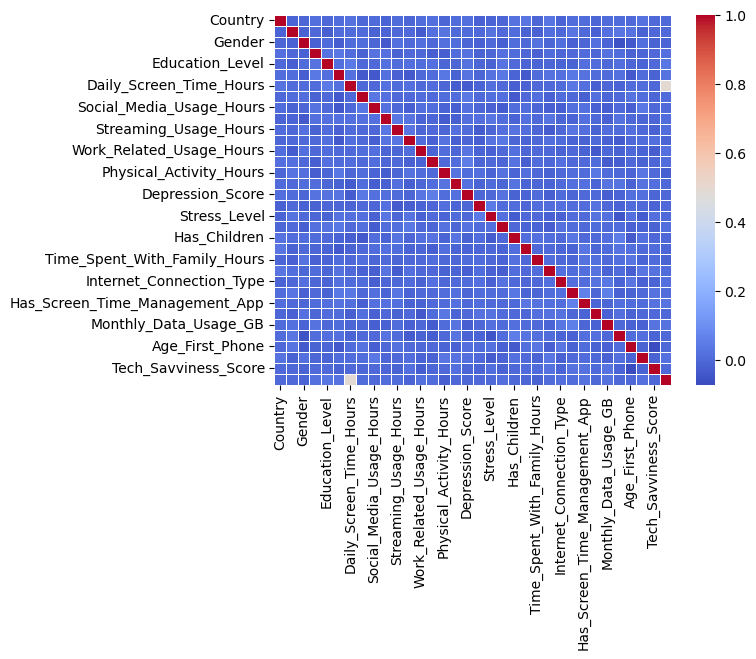

In [9]:
sns.heatmap(data_mobile.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
